# E-Commerce Competitive Intelligence Multi-Agent System
## Capstone Assignment - 8-Week Production-Grade Project

**Course**: Agentic AI Bootcamp - Staff-Level System Design

---

## Assignment Overview

In this capstone project, you will build a **production-grade multi-agent competitive intelligence system** for e-commerce. This assignment guides you through implementing:

- Real-time competitor pricing analysis with AI
- Product feature comparison using semantic understanding
- Automated competitive marketing content generation
- Product knowledge graphs for relationship mapping
- Full observability with Langfuse tracing

### How to Use This Assignment

1. **Read the context** - Each section explains the business problem and concepts
2. **Follow TODO markers** - Complete each `# TODO:` with your implementation
3. **Use hints** - `HINT:` comments provide guidance without giving answers
4. **Check expected output** - Verify your implementation matches expected results
5. **Run validation cells** - Each week ends with a checkpoint to verify completion

### Grading Rubric

| Component | Points | Criteria |
|-----------|--------|----------|
| Week 1-2: Foundation | 15 | Environment, data processing |
| Week 3: Vector Store | 15 | Semantic search implementation |
| Week 4: Single Agents | 25 | Three working agents with tracing |
| Week 5: Orchestration | 20 | Multi-agent coordination |
| Week 6: Knowledge Graph | 15 | Graph construction and queries |
| Week 7-8: Integration | 10 | Full system with UI |

### 8-Week Curriculum

| Week | Module | Key Deliverables |
|------|--------|------------------|
| 1 | Environment & Data Foundation | Langfuse setup, catalog loading, EDA |
| 2 | Document Processing | Catalog normalization, feature extraction |
| 3 | Vector Store & Embeddings | ChromaDB, semantic search |
| 4 | Single Agent Design | Price, Catalog, Marketing agents |
| 5 | Multi-Agent Orchestration | Parallel analysis, aggregation |
| 6 | Knowledge Graphs | Product taxonomy, relationships |
| 7-8 | Production Deployment | Full integration, Gradio UI |

---

# WEEK 1: Environment Setup & Langfuse Initialization

---

## Learning Objectives

By the end of Week 1, you will be able to:

- [ ] Configure a production-ready development environment
- [ ] Initialize Langfuse observability from the first line of code
- [ ] Understand e-commerce product data structures
- [ ] Perform exploratory data analysis on product catalogs
- [ ] Create traced wrapper functions for API calls

## Why Observability First?

In competitive intelligence, every AI decision can impact business outcomes:
- A pricing recommendation could affect millions in revenue
- Marketing claims must be factually defensible
- Feature comparisons need accuracy for legal compliance

**Langfuse provides the audit trail** that makes AI decisions transparent and reviewable.

## 1.1 Package Installation

Install all required packages. Each serves a specific purpose in our architecture.

In [1]:
# ============================================================================
# WEEK 1.1: PACKAGE INSTALLATION
# ============================================================================
# These packages are pre-configured - just run this cell

# Core LangChain packages
!pip install -q langchain==0.3.14 langchain-openai==0.3.0 langchain-community==0.3.14

# Observability
!pip install -q langfuse==2.57.1

# OpenAI
!pip install -q openai==1.59.6

# Vector store
!pip install -q chromadb==0.5.23

# Knowledge graph
!pip install -q networkx==3.4.2 pyvis==0.3.2

# Data processing
!pip install -q plotly seaborn

# Utilities
!pip install -q pydantic tenacity rich gradio python-dotenv

print("\n" + "="*50)
print("All packages installed successfully!")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 25.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.8 requires langchain-core>=1.0.0, but you have langchain-core 0.3.63 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.8/254.8 kB 13.

In [1]:
# ============================================================================
# CORE IMPORTS
# ============================================================================

import os
import sys
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any, Tuple
from dataclasses import dataclass, field
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

print("Core imports completed successfully")

Core imports completed successfully


## 1.2 Environment Detection & API Configuration

**TODO**: Complete the environment detection and API key loading logic.

In [2]:
# ============================================================================
# ENVIRONMENT DETECTION
# ============================================================================

# TODO: Detect if running in Google Colab
# HINT: Check if 'google.colab' is in sys.modules
IN_COLAB = 'google.colab' in sys.modules  # Replace with your detection logic

print(f"Environment Detection:")
print(f"  Running in Colab: {IN_COLAB}")
print(f"  Python version: {sys.version.split()[0]}")

Environment Detection:
  Running in Colab: True
  Python version: 3.12.13


In [4]:
# ============================================================================
# API KEY CONFIGURATION
# ============================================================================

# TODO: Implement API key loading for both Colab and local environments
#
# Requirements:
# 1. If IN_COLAB:
#    - Mount Google Drive
#    - Try loading from Colab Secrets (userdata.get())
#    - Fall back to getpass if secrets not available
# 2. If local:
#    - Load from .env file using python-dotenv
#
# Keys needed:
# - OPENAI_API_KEY
# - LANGFUSE_SECRET_KEY
# - LANGFUSE_PUBLIC_KEY
# - LANGFUSE_HOST (default: 'https://cloud.langfuse.com')

if IN_COLAB:
    # TODO: Implement Colab configuration
    # HINT: Use google.colab.drive.mount() and google.colab.userdata
    from google.colab import drive, userdata
    drive.mount('/content/drive')

 
   # Enhanced Drive Path Detection - Multiple possible .env locations
    env_candidates = [
        '/content/drive/MyDrive/.env',
        '/content/drive/MyDrive/ClinicalIQ/.env',
        '/content/drive/MyDrive/Colab Notebooks/.env',
        '/content/drive/MyDrive/pwc-agenticai-capstone/.env',
        '/content/drive/MyDrive/Agentic AI/.env',
        '/content/drive/MyDrive/IK Agentic AI/.env'
    ]
    
    print("🔍 Searching for .env file in Google Drive...")
    env_loaded = False
    
    for env_path in env_candidates:
        print(f"   Checking: {env_path}")
        if os.path.exists(env_path):
            print(f"✅ Found .env file at: {env_path}")
            
            from dotenv import load_dotenv
            load_dotenv(env_path)
            env_loaded = True
            break            

    if not env_loaded:
        print("📁 No .env file found or incomplete. Trying Colab Secrets...")
        try:
            os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
            os.environ['LANGFUSE_SECRET_KEY'] = userdata.get('LANGFUSE_SECRET_KEY')
            os.environ['LANGFUSE_PUBLIC_KEY'] = userdata.get('LANGFUSE_PUBLIC_KEY')
            os.environ['LANGFUSE_HOST'] = "https://us.cloud.langfuse.com"
            
            print("✅ API keys loaded from Colab Secrets (fallback)")
        except Exception as e:
            print("❌ Failed to load API keys from Colab Secrets. Please set them manually.")
            print(f"Error: {e}")
            # Optionally, you could use getpass here to prompt for keys if both methods fail  
            
    DATA_DIR_BASE = '/content/drive/MyDrive/pwc-agenticai-capstone/datasets/competeIq'

else:
    # TODO: Implement local configuration
    # HINT: Use dotenv.load_dotenv()
    from dotenv import load_dotenv
    env_path = Path('.').resolve() / '.env'
    load_dotenv(env_path)
    env_loaded = True

    DATA_DIR_BASE = str(Path('.').resolve() / 'datasets')

#  Validate that required keys are present
assert os.environ.get('OPENAI_API_KEY'), "OPENAI_API_KEY not found"
assert os.environ.get('LANGFUSE_SECRET_KEY'), "LANGFUSE_SECRET_KEY not found"

DATA_DIR = Path(DATA_DIR_BASE)



Mounted at /content/drive
🔍 Searching for .env file in Google Drive...
   Checking: /content/drive/MyDrive/.env
   Checking: /content/drive/MyDrive/ClinicalIQ/.env
   Checking: /content/drive/MyDrive/Colab Notebooks/.env
   Checking: /content/drive/MyDrive/pwc-agenticai-capstone/.env
✅ Found .env file at: /content/drive/MyDrive/pwc-agenticai-capstone/.env


In [5]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================

PROJECT_NAME = "ecommerce-competitive-intelligence"


print("\nProject Configuration:")
print(f"  Project Name: {PROJECT_NAME}")
print(f"  Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"  Data Directory: {DATA_DIR}")
print("\nAPI keys configured")


Project Configuration:
  Project Name: ecommerce-competitive-intelligence
  Environment: Google Colab
  Data Directory: /content/drive/MyDrive/pwc-agenticai-capstone/datasets/competeIq

API keys configured


## 1.3 Langfuse Initialization

Initialize Langfuse - the foundation of our observability strategy.

**TODO**: Initialize Langfuse client and verify the connection.

In [ ]:
# ============================================================================
# WEEK 1.3: LANGFUSE INITIALIZATION
# ============================================================================

from langfuse import Langfuse
from langfuse.callback import CallbackHandler as LangfuseCallbackHandler
from openai import OpenAI

langfuse = Langfuse(secret_key = os.environ['LANGFUSE_SECRET_KEY'],
                    public_key= os.environ['LANGFUSE_PUBLIC_KEY'],
                    host= os.environ['LANGFUSE_HOST'] )
print (os.environ['LANGFUSE_SECRET_KEY'][:10], " , ", 
       os.environ['LANGFUSE_PUBLIC_KEY'][:10], ", ", 
       os.environ['LANGFUSE_HOST'][:10])

# verify connection
langfuse.auth_check()

#create session
SESSION_ID = f"contractIQ-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Initialize OpenAI client
openai_client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

print(f"Session ID: {SESSION_ID}")

print("Langfuse initialization complete")

sk-lf-98eb7534-5d08-4dbf-950f-ef9f4f10040d  ,  pk-lf-df894277-c211-42ec-9b9c-ceb6b3ca1139 ,  https://us.cloud.langfuse.com
sk-lf-98eb  ,  pk-lf-df89 ,  https://us
Session ID: contractIQ-20260413-070131
Langfuse initialization complete


In [10]:
# ============================================================================
# SESSION CONFIGURATION
# ============================================================================


print(f"\nSession Configuration:")
print(f"  Session ID: {SESSION_ID}")
print(f"  Langfuse Host: {os.environ.get('LANGFUSE_HOST')}")


Session Configuration:
  Session ID: contractIQ-20260413-070131
  Langfuse Host: https://us.cloud.langfuse.com


## 1.4 Traced Wrapper Functions

Create wrapper functions that automatically trace all OpenAI API calls.

**TODO**: Implement traced embedding and completion functions.

In [12]:
# ============================================================================
# TODO: TRACED EMBEDDING FUNCTION
# ============================================================================

def traced_embedding(
    text: str,
    trace_name: str = "embedding",
    metadata: Dict = None
) -> List[float]:
    """
    Generate embedding with full Langfuse tracing.
    
    Args:
        text: The text to embed
        trace_name: Name for the Langfuse trace
        metadata: Additional metadata to log with the trace
    Returns:
        List of floats representing the embedding vector

    """
    # 1. Create a Langfuse trace with the given name and session_id
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, metadata={})
    
    #2. Create a generation span for the embedding call
    generation = trace.generation(name="openai-embedding", model="text-embedding-3-small", input=text)

    #3. Call OpenAI embeddings API (model: text-embedding-3-small)
    response = openai_client.embeddings.create(input=[text], model="text-embedding-3-small")
    
    #4. Log the output and usage to the generation
    embedding = response.data[0].embedding
    
    # Format usage data properly for Langfuse
    usage_data = {
        "promptTokens": response.usage.prompt_tokens if response.usage else 0,
        "completionTokens": 0,  # Embeddings don't have completion tokens
        "totalTokens": response.usage.total_tokens if response.usage else 0
    }

    generation.end(output=embedding, usage=usage_data)

    # 5. Return the embedding vector
    return embedding


print("traced_embedding() function defined successfully")

traced_embedding() function defined successfully


In [13]:
# ============================================================================
# TODO: TRACED COMPLETION FUNCTION
# ============================================================================

def traced_completion(
    prompt: str,
    system: str = "",
    trace_name: str = "completion",
    model: str = "gpt-4o-mini",
    temperature: float = 0,
    metadata: Dict = None
) -> str:
    """
    Generate completion with full Langfuse tracing.
    Args:
        prompt: User prompt
        system: System message
        trace_name: Name for the trace
        model: Model to use
        temperature: Sampling temperature
        metadata: Additional metadata

    Returns:
        Model response text

    HINTS:
    - Response text is at: response.choices[0].message.content
    - Token counts are at: response.usage.prompt_tokens, completion_tokens, total_tokens
    """
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID,
                           metadata={
                               "operation": "competeIq_completion",
                               "model": model,
                               "temperature": temperature,
                               "prompt_length": len(prompt),
                               "has_system": bool(system)
                               }
                           )

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
        ]

    generation = trace.generation(
        name="openai_chatcompletions",
        model=model,
        input=messages,
        model_parameters={
            "temperature": temperature,
            "max_tokens": None
        }
    )

    response = openai_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature = temperature
        )

    completion_text = response.choices[0].message.content

    # Close the span with results and usage stats
    generation.end(
        output=completion_text,
        usage={
            "promptTokens": response.usage.prompt_tokens if response.usage else 0,
            "completionTokens": response.usage.completion_tokens if response.usage else 0,
            "totalTokens": response.usage.total_tokens if response.usage else 0
        })

    return completion_text


print("traced_completion() function defined successfully")

traced_completion() function defined successfully


In [16]:
# ============================================================================
# LANGCHAIN CALLBACK HANDLER
# ============================================================================

def get_langfuse_handler(
    trace_name: str,
    tags: List[str] = None
) -> LangfuseCallbackHandler:
    """
    Get a LangChain callback handler for automatic tracing.

    Args:
        trace_name: Name for the trace
        tags: Optional list of tags

    Returns:
        Configured LangfuseCallbackHandler

    """
    try:
        return LangfuseCallbackHandler(
            secret_key=os.environ.get('LANGFUSE_SECRET_KEY'),
            public_key=os.environ.get('LANGFUSE_PUBLIC_KEY'),
            host=os.environ.get('LANGFUSE_HOST'),
            session_id=SESSION_ID if 'SESSION_ID' in globals() else "default_session",
            trace_name=trace_name,
            tags=tags or []
        )
    except Exception as e:
        print(f"❌ LangChain callback handler creation failed: {e}")
        raise

print("get_langfuse_handler() function defined successfully")

get_langfuse_handler() function defined successfully


## 1.5 E-Commerce Product Catalogs

Load the product data. These catalogs represent two competing companies.

In [14]:
# ============================================================================
# PRODUCT CATALOG - COMPANY X (Our Company)
# ============================================================================
# This data is provided - just run this cell

COMPANY_X_CATALOG = {
    "company": "Company X",
    "description": "Premium consumer electronics brand",
    "products": [
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones X1",
            "price": 99.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Noise Cancelling", "20h Battery", "Foldable"],
            "discount": "10% off",
            "availability": "In Stock",
            "sku": "X1-HP-001"
        },
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones X2 Pro",
            "price": 149.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Advanced ANC", "30h Battery", "Foldable", "USB-C", "Multipoint"],
            "discount": None,
            "availability": "In Stock",
            "sku": "X2-HP-002"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch X1",
            "price": 199.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "5 Day Battery", "Water Resistant", "Sleep Tracking"],
            "discount": "15% off",
            "availability": "In Stock",
            "sku": "X1-SW-001"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch X2 Ultra",
            "price": 349.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "ECG", "10 Day Battery", "Titanium", "Dive Mode"],
            "discount": None,
            "availability": "Limited Stock",
            "sku": "X2-SW-002"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker X1",
            "price": 79.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Waterproof", "12h Battery", "360 Sound"],
            "discount": None,
            "availability": "In Stock",
            "sku": "X1-SP-001"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker X2 Party",
            "price": 149.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Waterproof", "24h Battery", "LED Lights", "Mic Input"],
            "discount": "20% off",
            "availability": "In Stock",
            "sku": "X2-SP-002"
        }
    ]
}

print(f"Company X Catalog Loaded: {len(COMPANY_X_CATALOG['products'])} products")

Company X Catalog Loaded: 6 products


In [15]:
# ============================================================================
# PRODUCT CATALOG - COMPANY Y (Competitor)
# ============================================================================

COMPANY_Y_CATALOG = {
    "company": "Company Y",
    "description": "Value-focused consumer electronics",
    "products": [
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones Z1",
            "price": 105.00,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Noise Cancelling", "25h Battery", "Quick Charge", "Foldable"],
            "discount": "5% off + Free Case",
            "availability": "In Stock",
            "sku": "Z1-HP-001"
        },
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones Z2",
            "price": 115.00,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Advanced Noise Cancelling", "30h Battery", "Waterproof"],
            "discount": None,
            "availability": "In Stock",
            "sku": "Z2-HP-002"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch Z1",
            "price": 189.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "7 Day Battery", "Water Resistant", "Sleep Tracking", "SpO2"],
            "discount": "20% off",
            "availability": "In Stock",
            "sku": "Z1-SW-001"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch Z2 Sport",
            "price": 279.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "5 Day Battery", "100+ Workouts", "Voice Assistant"],
            "discount": "10% off",
            "availability": "In Stock",
            "sku": "Z2-SW-002"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker Z1",
            "price": 69.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Waterproof", "15h Battery", "Stereo Pairing"],
            "discount": "Free Shipping",
            "availability": "In Stock",
            "sku": "Z1-SP-001"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker Z2 Boom",
            "price": 129.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "IP67 Rating", "20h Battery", "Bass Boost", "Daisy Chain"],
            "discount": None,
            "availability": "In Stock",
            "sku": "Z2-SP-002"
        }
    ]
}

print(f"Company Y Catalog Loaded: {len(COMPANY_Y_CATALOG['products'])} products")

Company Y Catalog Loaded: 6 products


## 1.6 Exploratory Data Analysis (EDA)

**TODO**: Build a DataFrame and analyze the product catalogs.

In [17]:
# ============================================================================
# TODO: BUILD EDA DATAFRAME
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Create a list of dictionaries containing product data from both catalogs
# Each dictionary should have:
# - company: Company name
# - category: Product category
# - product: Product name
# - base_price: Original price
# - discount_pct: Discount percentage (parse from discount string, e.g., "10% off" -> 10)
# - effective_price: base_price * (1 - discount_pct/100)
# - feature_count: Number of features
# - has_discount: Boolean
#
# HINT: Use regex re.search(r'(\d+)%', discount_str) to extract percentage

def catalog_to_eda_rows(catalog: Dict) -> List[Dict]:
    rows = []

    for product in catalog['products']:
        discount_str = product.get('discount') or ''
        discount_match = re.search(r'(\d+)%', discount_str)
        discount_pct = int(discount_match.group(1)) if discount_match else 0
        base_price = product['price']

        rows.append({
            'company': catalog['company'],
            'category': product['category'],
            'product': product['product_name'],
            'base_price': base_price,
            'discount_pct': discount_pct,
            'effective_price': round(base_price * (1 - discount_pct / 100), 2),
            'feature_count': len(product['features']),
            'has_discount': product.get('discount') is not None
        })

    return rows


eda_data = catalog_to_eda_rows(COMPANY_X_CATALOG) + catalog_to_eda_rows(COMPANY_Y_CATALOG)

# Create DataFrame
eda_df = pd.DataFrame(eda_data)

print("EDA DataFrame created")
print(f"Shape: {eda_df.shape}")
print(f"Columns: {list(eda_df.columns)}")

EDA DataFrame created
Shape: (12, 8)
Columns: ['company', 'category', 'product', 'base_price', 'discount_pct', 'effective_price', 'feature_count', 'has_discount']


In [18]:
# ============================================================================
# TODO: EDA SUMMARY STATISTICS
# ============================================================================

print("PRODUCT CATALOG SUMMARY")
print("="*60)

# TODO: Display the following statistics:
# 1. Total number of products
# 2. Products by company (use value_counts())
# 3. Products by category
# 4. Average effective price by company (use groupby)
# 5. Number of products with discounts

# Expected output format:
# Total products: 12
# Products by Company:
#   Company X    6
#   Company Y    6
# etc.

print(f"Total products: {len(eda_df)}")

print("\nProducts by Company:")
print(eda_df['company'].value_counts().to_string())

print("\nProducts by Category:")
print(eda_df['category'].value_counts().to_string())

print("\nAverage Effective Price by Company:")
avg_price_by_company = eda_df.groupby('company')['effective_price'].mean().round(2)
print(avg_price_by_company.to_string())

print("\nProducts with Discounts:")
print(int(eda_df['has_discount'].sum()))

PRODUCT CATALOG SUMMARY
Total products: 12

Products by Company:
company
Company X    6
Company Y    6

Products by Category:
category
Wireless Headphones    4
Smart Watches          4
Portable Speakers      4

Average Effective Price by Company:
company
Company X    159.99
Company Y    136.45

Products with Discounts:
7


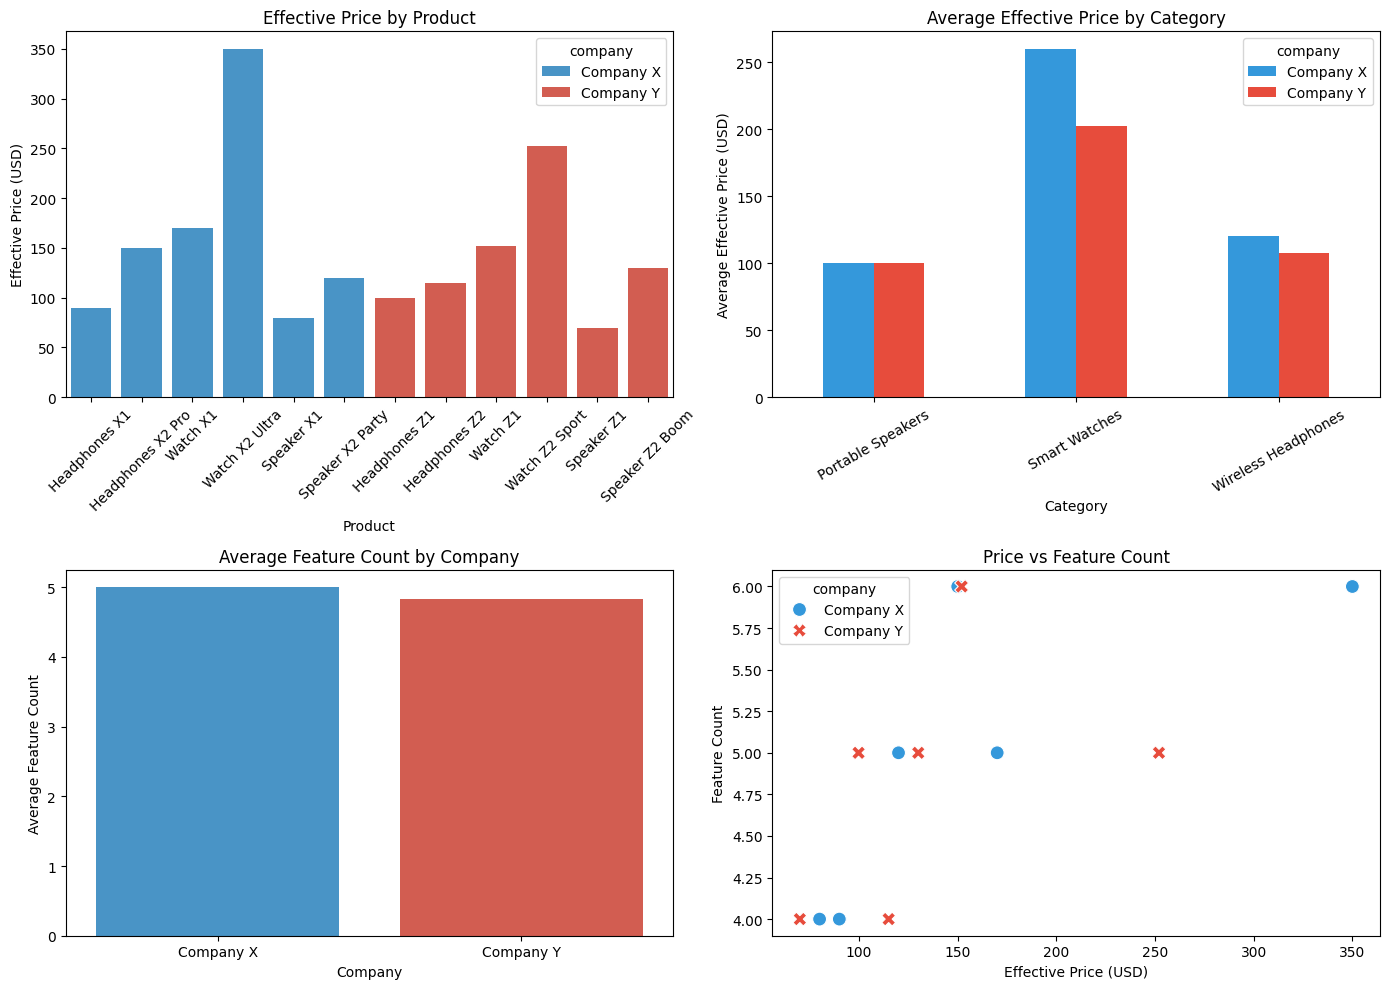

EDA visualization saved to ecommerce_eda.png


In [19]:
# ============================================================================
# TODO: EDA VISUALIZATION
# ============================================================================

# TODO: Create a 2x2 subplot figure showing:
# 1. Effective price comparison by product (bar chart)
# 2. Average price by category and company (grouped bar chart)
# 3. Average feature count by company (bar chart)
# 4. Scatter plot of price vs feature count, colored by company
#
# HINTS:
# - Use fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# - Company colors: {'Company X': '#3498db', 'Company Y': '#e74c3c'}
# - Save the figure as 'ecommerce_eda.png'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
company_colors = {'Company X': '#3498db', 'Company Y': '#e74c3c'}

# 1. Effective price comparison by product
sns.barplot(
    data=eda_df,
    x='product',
    y='effective_price',
    hue='company',
    palette=company_colors,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Effective Price by Product')
axes[0, 0].set_xlabel('Product')
axes[0, 0].set_ylabel('Effective Price (USD)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average price by category and company
avg_price_by_category = eda_df.pivot_table(
    index='category',
    columns='company',
    values='effective_price',
    aggfunc='mean'
)
avg_price_by_category.plot(
    kind='bar',
    color=[company_colors[company] for company in avg_price_by_category.columns],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average Effective Price by Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Average Effective Price (USD)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Average feature count by company
avg_features_by_company = eda_df.groupby('company', as_index=False)['feature_count'].mean()
sns.barplot(
    data=avg_features_by_company,
    x='company',
    y='feature_count',
    hue='company',
    palette=company_colors,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Average Feature Count by Company')
axes[1, 0].set_xlabel('Company')
axes[1, 0].set_ylabel('Average Feature Count')

# 4. Price vs feature count scatter plot
sns.scatterplot(
    data=eda_df,
    x='effective_price',
    y='feature_count',
    hue='company',
    style='company',
    palette=company_colors,
    s=100,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Price vs Feature Count')
axes[1, 1].set_xlabel('Effective Price (USD)')
axes[1, 1].set_ylabel('Feature Count')

plt.tight_layout()
plt.savefig('ecommerce_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA visualization saved to ecommerce_eda.png")

## Week 1 Checkpoint

Run this cell to verify your Week 1 implementation.

In [20]:
# ============================================================================
# WEEK 1 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 1 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("IN_COLAB is defined", IN_COLAB is not None),
    ("Langfuse initialized", langfuse is not None),
    ("SESSION_ID created", SESSION_ID is not None and len(str(SESSION_ID)) > 0),
    ("OpenAI client ready", openai_client is not None),
    ("traced_embedding() implemented", traced_embedding is not None and traced_embedding.__code__.co_code != b'd\x00S\x00'),
    ("traced_completion() implemented", traced_completion is not None and traced_completion.__code__.co_code != b'd\x00S\x00'),
    ("get_langfuse_handler() implemented", get_langfuse_handler is not None),
    ("Company X catalog loaded", len(COMPANY_X_CATALOG['products']) == 6),
    ("Company Y catalog loaded", len(COMPANY_Y_CATALOG['products']) == 6),
    ("EDA DataFrame created", 'eda_df' in dir() and len(eda_df) == 12),
]

passed = 0
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    icon = "[OK]" if check_result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if check_result:
        passed += 1

print("\n" + "="*60)
print(f"Week 1 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 1 Complete! Proceed to Week 2.")
else:
    print("Review failed checks before continuing.")

WEEK 1 CHECKPOINT - Verification
  [OK] IN_COLAB is defined: PASS
  [OK] Langfuse initialized: PASS
  [OK] SESSION_ID created: PASS
  [OK] OpenAI client ready: PASS
  [OK] traced_embedding() implemented: PASS
  [OK] traced_completion() implemented: PASS
  [OK] get_langfuse_handler() implemented: PASS
  [OK] Company X catalog loaded: PASS
  [OK] Company Y catalog loaded: PASS
  [OK] EDA DataFrame created: PASS

Week 1 Score: 10/10 checks passed
Week 1 Complete! Proceed to Week 2.
